Version: 1.0
Pre-tokenizer: Whitespace
Model type: BPE
unk_token: [UNK]
byte_fallback: False
Post-processor: None
Normalizer: None
Special tokens: {'[UNK]': 0, '[CLS]': 1, '[SEP]': 2, '[PAD]': 3, '[MASK]': 4}
Vocab size (incl. specials): 30000

Token-length (bp) distribution:
   1 bp : 5
   2 bp : 17
   3 bp : 37
   4 bp : 103
   5 bp : 371
   6 bp : 1,280
   7 bp : 3,447
   8 bp : 3,778
   9 bp : 2,408
  10 bp : 1,654
  11 bp : 1,168
  12 bp : 1,009
  13 bp : 808
  14 bp : 750
  15 bp : 672
  16 bp : 602
  17 bp : 577
  18 bp : 451
  19 bp : 417
  20 bp : 373
  21 bp : 328
  22 bp : 345
  23 bp : 299
  24 bp : 311
  25 bp : 274
  26 bp : 244
  27 bp : 224
  28 bp : 186
  29 bp : 222
  30 bp : 207
  31 bp : 176
  32 bp : 174
  33 bp : 149
  34 bp : 156
  35 bp : 175
  36 bp : 141
  37 bp : 139
  38 bp : 117
  39 bp : 124
  40 bp : 123
  41 bp : 117
  42 bp : 121
  43 bp : 109
  44 bp : 104
  45 bp : 101
  46 bp : 84
  47 bp : 87
  48 bp : 95
  49 bp : 61
  50 bp : 71
  51 bp : 69
  52 

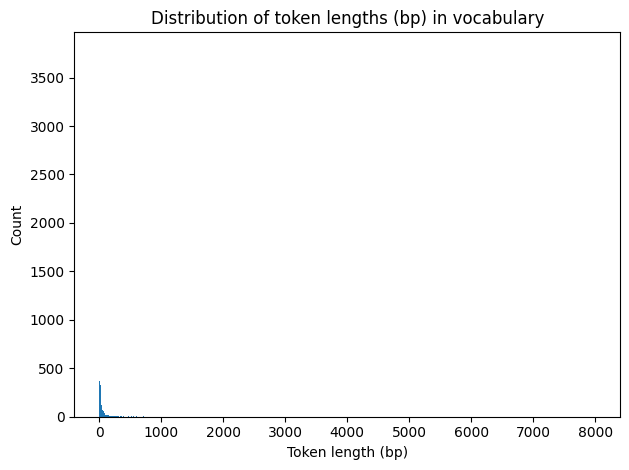

In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict
import re

# Optional: plotting
import matplotlib.pyplot as plt

tok_path = Path("/cs/student/projects1/aibh/2024/acunning/Projects/models/addgene_trained_dna_tokenizer.json")

with tok_path.open() as f:
    tok = json.load(f)

# --- Basic inspection ---
print("Version:", tok.get("version"))
print("Pre-tokenizer:", tok.get("pre_tokenizer", {}).get("type"))
print("Model type:", tok.get("model", {}).get("type"))
print("unk_token:", tok.get("model", {}).get("unk_token"))
print("byte_fallback:", tok.get("model", {}).get("byte_fallback"))
print("Post-processor:", tok.get("post_processor"))
print("Normalizer:", tok.get("normalizer"))

# Special tokens (by content and id)
added = tok.get("added_tokens", []) or []
special_id_by_content = {t["content"]: t["id"] for t in added if t.get("special")}
special_contents = set(special_id_by_content.keys())
print("Special tokens:", special_id_by_content)

# --- Extract vocab (content -> id) ---
vocab = tok.get("model", {}).get("vocab", {})
print("Vocab size (incl. specials):", len(vocab))

# Identify specials either from added_tokens or by bracketed names in vocab
def is_special(token_str: str) -> bool:
    if token_str in special_contents:
        return True
    # Fallback heuristic: bracketed tokens like [PAD]
    return bool(re.fullmatch(r"\[[A-Z]+\]", token_str))

# Build list of non-special tokens and their lengths
non_special = []
for token_str, tid in vocab.items():
    if not is_special(token_str):
        non_special.append(token_str)

# Token length distribution
lengths = [len(t) for t in non_special]
cnt = Counter(lengths)

print("\nToken-length (bp) distribution:")
for L in sorted(cnt):
    print(f"  {L:>2} bp : {cnt[L]:,}")

print(f"\nNon-special token count: {len(non_special):,}")
print(f"Min length: {min(lengths) if lengths else 'NA'}")
print(f"Max length: {max(lengths) if lengths else 'NA'}")

# Show a few of the longest tokens
k = 20
longest = sorted(non_special, key=len, reverse=True)[:k]
print(f"\nTop {k} longest tokens (len, token):")
for t in longest:
    print(len(t), t)

# Check for any tokens containing characters outside A,C,G,T,N
allowed = set("ACGTN")
weird = [t for t in non_special if any(ch not in allowed for ch in t)]
if weird:
    weird_counts = Counter(ch for t in weird for ch in t if ch not in allowed)
    print("\n⚠️ Tokens with non-ACGTN characters detected:")
    print("  Non-ACGTN char frequencies:", dict(weird_counts))
    print("  Example tokens:", weird[:20])
else:
    print("\nAll non-special tokens are composed of A/C/G/T/N only.")

# Plot a simple histogram of token lengths
plt.figure()
plt.hist(lengths, bins=range(1, (max(lengths) if lengths else 1)+2), align="left")
plt.xlabel("Token length (bp)")
plt.ylabel("Count")
plt.title("Distribution of token lengths (bp) in vocabulary")
plt.tight_layout()
plt.show()


In [2]:
import json
from pathlib import Path

tok_path = Path("/cs/student/projects1/aibh/2024/acunning/Projects/models/addgene_trained_dna_tokenizer.json")

with tok_path.open() as f:
    tok = json.load(f)

specials = {t["content"] for t in tok.get("added_tokens", []) if t.get("special")}
vocab = tok["model"]["vocab"]

def is_special(tok: str) -> bool:
    return tok in specials or (tok.startswith("[") and tok.endswith("]"))

non_special_tokens = [t for t in vocab.keys() if not is_special(t)]

# lengths
lengths = {t: len(t) for t in non_special_tokens}
over_400 = [t for t, L in lengths.items() if L > 400]

print(f"Vocab size (incl specials): {len(vocab):,}")
print(f"Non-special tokens: {len(non_special_tokens):,}")
print(f"Tokens > 400 bp: {len(over_400):,}")

if non_special_tokens:
    max_tok = max(non_special_tokens, key=lambda t: len(t))
    print(f"Max token length: {len(max_tok)} bp")
    print("Example long tokens (>400 bp):")
    for t in over_400[:5]:
        print(f"  len={len(t)}  token(head)={t[:60]}...")


Vocab size (incl specials): 30,000
Non-special tokens: 29,995
Tokens > 400 bp: 696
Max token length: 8001 bp
Example long tokens (>400 bp):
  len=498  token(head)=TTCTAGTGTAGCCGTAGTTAGGCCACCACTTCAAGAACTCTGTAGCACCGCCTACATACC...
  len=537  token(head)=TTCTAGTGTAGCCGTAGTTAGGCCACCACTTCAAGAACTCTGTAGCACCGCCTACATACC...
  len=498  token(head)=TGTGAGCAAAAGGCCAGCAAAAGGCCAGGAACCGTAAAAAGGCCGCGTTGCTGGCGTTTT...
  len=569  token(head)=TACAGGCATCGTGGTGTCACGCTCGTCGTTTGGTATGGCTTCATTCAGCTCCGGTTCCCA...
  len=629  token(head)=GTATTTGGTATCTGCGCTCTGCTGAAGCCAGTTACCTTCGGAAAAAGAGTTGGTAGCTCT...


In [ ]:
import json
from pathlib import Path
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

# Paths
tok_path = Path("/cs/student/projects1/aibh/2024/acunning/Projects/models/addgene_trained_dna_tokenizer.json")
out_fasta = Path("/cs/student/projects1/aibh/2024/acunning/Projects/Results/tokens_over400.fasta")

# Load tokenizer
with tok_path.open() as f:
    tok = json.load(f)

specials = {t["content"] for t in tok.get("added_tokens", []) if t.get("special")}
vocab = tok["model"]["vocab"]

def is_special(tok: str) -> bool:
    return tok in specials or (tok.startswith("[") and tok.endswith("]"))

# Collect long tokens
records = []
for token, idx in vocab.items():
    if not is_special(token) and len(token) > 400:
        rec = SeqRecord(Seq(token), id=f"token_{idx}", description=f"length={len(token)}")
        records.append(rec)

# Write FASTA
SeqIO.write(records, out_fasta, "fasta")

print(f" Saved {len(records)} tokens >400 bp to {out_fasta}")


✅ Saved 696 tokens >400 bp to /cs/student/projects1/aibh/2024/acunning/Projects/Results/tokens_over400.fasta


In [1]:
from Bio import SeqIO
from pathlib import Path

# Input and output paths
input_fasta = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/tokens_over400.fasta"
output_dir = "/cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences"

# Create output directory if it doesn't exist
Path(output_dir).mkdir(exist_ok=True)

# Split sequences into individual files
for record in SeqIO.parse(input_fasta, "fasta"):
    output_file = f"{output_dir}/{record.id}.fasta"
    SeqIO.write(record, output_file, "fasta")
    print(f"Wrote {record.id} to {output_file}")

Wrote token_1067 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1067.fasta
Wrote token_1511 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1511.fasta
Wrote token_1516 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1516.fasta
Wrote token_1811 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1811.fasta
Wrote token_1965 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1965.fasta
Wrote token_1980 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_1980.fasta
Wrote token_2032 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_2032.fasta
Wrote token_2066 to /cs/student/projects1/aibh/2024/acunning/Projects/Results/individual_sequences/token_2066.fasta
Wrote token_2096 to /cs/student/projects1/aibh/2024/acunning/Projects/Re